In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
!pip3 install tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.7 MB/s eta 0:00:00


In [3]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

## Load in Data

In [4]:
# start from the sampled dataframe
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/Current Worksheet versions/Varying Input sizes/200_step_samples_forAll.csv')


In [5]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [6]:
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

In [7]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

sensor_place
93    342000
8B    342000
9B    342000
B6    342000
95    342000
CC    342000
Name: count, dtype: int64

In [8]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)

In [9]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

trial_label
GR      216000
BNKR    216000
BNKL    216000
SLPD    216000
SLPU    216000
STD     216000
STU     216000
CS      216000
FE      216000
Name: count, dtype: int64

In [10]:
all_samples = all_samples.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])

In [11]:
# seperating inputs by the sensor placement
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "B6"] # left shank

In [12]:
# list of all of the separated dfs
sensor_dfs = [all_samples_93]

In [13]:
all_sensor_metrics = []
all_sensor_non_metrics = []

for df in sensor_dfs:
    sensor_df_metrics = []
    metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                            ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                            ' VelInc_Z', ' Yaw', ' Pitch', ' Roll'])

    # normalize
    metrics = MinMaxScaler().fit_transform(metrics)
    # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
    numpy_metrics = metrics
    reshape_metrics = np.reshape(numpy_metrics, (1620, 200, 18))
    sensor_df_metrics.append(reshape_metrics)
    all_sensor_metrics.append(sensor_df_metrics)


    # dataframe of the non measurements
    non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
    # reducing the trial label column down to just 1 label per sequence
    drop_doop = non_metrics.drop_duplicates()
    # one hot encode the surface labels (outcome labels)
    label_encoder = LabelEncoder()
    integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
    one_hot_encoded_labels = to_categorical(integer_encoded_labels)
    # make encoded variable into numpy
    numpy_result = np.array(one_hot_encoded_labels)
    reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
    all_sensor_non_metrics.append(reshape_non_metrics)


In [14]:
len(all_sensor_metrics)

1

## Setting up X and Y train/test

In [15]:
X_93 = np.array(all_sensor_metrics[0])
Y_93 = np.array(all_sensor_non_metrics[0])

index_split = list(range(1620))
# train, test = train_test_split(index_split, test_size=0.15)

X_93 = X_93.squeeze()

In [16]:
# check variables
n_obs, n_timesteps, n_features, n_classes = 1377, 200, 18, 9

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional

# clears the session for tensorflow
tf.keras.backend.clear_session()

# Define input shape
input_shape = (n_timesteps, n_features)
number_of_inputs = len(all_sensor_metrics)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
labels = []
count = 0


input_layer = Input(shape=input_shape)
inputs.append(input_layer)
# CNN layer
cnn_out = BatchNormalization()(input_layer)
cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = Dropout(0.4)(cnn_out)
# Bidirectional LSTM layer
lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)
# Attention layer
attention = Attention()([cnn_out, lstm_out])
# # Concatenate attention output with LSTM output
merged = Concatenate(axis=-1)([lstm_out, attention])

# MLP layer
mlp_out = Flatten()(merged)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)
# Create the model
model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Print the model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200, 18)]            0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 200, 18)              72        ['input_1[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 conv1d (Conv1D)             (None, 198, 128)             7040      ['batch_normalization[0][0]'] 
                                                                                                  
 max_pooling1d (MaxPooling1  (None, 99, 128)              0         ['conv1d[0][0]']          

# Hyperparameter tuning

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

# Split data into train-validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_93, Y_93, test_size=0.2)

# Define search space for hyperparameters
space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.0001), np.log(0.001)),
    'dropout_rate': hp.uniform('dropout_rate', 0.1, 0.5),
    'num_units_lstm': hp.choice('num_units_lstm', [32, 64, 128]),
    'num_filters_cnn': hp.choice('num_filters_cnn', [64, 128, 256]),
}

# Define objective function
def objective(params):
    # Define the model
    input_shape = (sequence_length, feature_dim)
    input_layer = Input(shape=input_shape)
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=params['num_filters_cnn'], kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(params['dropout_rate'])(cnn_out)
    cnn_out = Dense(units=params['num_units_lstm'], activation='relu')(cnn_out)  # Adjusted
    lstm_out = Bidirectional(LSTM(units=params['num_units_lstm'], dropout=params['dropout_rate'], recurrent_dropout=params['dropout_rate'], return_sequences=True))(cnn_out)
    attention = Attention()([lstm_out, lstm_out])  # Adjusted
    merged = Concatenate(axis=-1)([lstm_out, attention])
    mlp_out = Flatten()(merged)
    mlp_out = Dense(units=128, activation='relu')(mlp_out)
    mlp_out = Dense(units=64, activation='relu')(mlp_out)
    output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Early stopping callback
    callback = EarlyStopping(monitor='val_loss', patience=10)

    # Train the model
    history = model.fit(x=X_train_val, y=y_train_val, validation_split=0.2, epochs=200, batch_size=128, callbacks=[callback])

    # Evaluate the model on the validation set
    loss, accuracy = model.evaluate(X_test, y_test)

    return {'loss': -accuracy, 'status': STATUS_OK}

# Run Hyperopt optimization
trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=30, trials=trials)

print("Best Hyperparameters:", best)


Streaming output truncated to the last 5000 lines.
9/9 [==============================] - 1s 140ms/step - loss: 0.8386 - accuracy: 0.6950 - val_loss: 1.7070 - val_accuracy: 0.4000

Epoch 28/200

9/9 [==============================] - 1s 141ms/step - loss: 0.8317 - accuracy: 0.7075 - val_loss: 1.6752 - val_accuracy: 0.4269

Epoch 29/200

9/9 [==============================] - 1s 144ms/step - loss: 0.7952 - accuracy: 0.7201 - val_loss: 1.6748 - val_accuracy: 0.4538

Epoch 30/200

9/9 [==============================] - 1s 140ms/step - loss: 0.7584 - accuracy: 0.7346 - val_loss: 1.6118 - val_accuracy: 0.4385

Epoch 31/200

9/9 [==============================] - 1s 147ms/step - loss: 0.7680 - accuracy: 0.7278 - val_loss: 1.7135 - val_accuracy: 0.4500

Epoch 32/200

9/9 [==============================] - 1s 142ms/step - loss: 0.7875 - accuracy: 0.7085 - val_loss: 1.4769 - val_accuracy: 0.4962

Epoch 33/200

9/9 [==============================] - 1s 141ms/step - loss: 0.7333 - accuracy: 0.743

In [19]:
# Extract best hyperparameters and their corresponding validation accuracy
best_params = trials.best_trial['misc']['vals']
best_accuracy = -trials.best_trial['result']['loss']  # Note the negative sign as we minimized the negative validation accuracy

print("Best Hyperparameters:")
print("Learning Rate:", best_params['learning_rate'][0])
print("Dropout Rate:", best_params['dropout_rate'][0])
print("Number of LSTM Units:", [32, 64, 128][best_params['num_units_lstm'][0]])
print("Number of CNN Filters:", [64, 128, 256][best_params['num_filters_cnn'][0]])
print("Best Validation Accuracy:", best_accuracy)


Best Hyperparameters:
Learning Rate: 0.00011548367272591061
Dropout Rate: 0.48616512684876134
Number of LSTM Units: 32
Number of CNN Filters: 128
Best Validation Accuracy: 0.8209876418113708


## Train Model

In [21]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

# Split data into train-validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_93, Y_93, test_size=0.15)

# Initialize KFold with desired number of folds
kfold = KFold(n_splits=10, shuffle=True)

# Initialize lists to store evaluation metrics
accuracies = []
conf_matrices = []

# Perform k-fold cross-validation
for train_index, test_index in kfold.split(X_train_val):
    x_train, x_valid = X_train_val[train_index], X_train_val[test_index]
    y_train, y_valid = y_train_val[train_index], y_train_val[test_index]

    # clears the session for tensorflow
    tf.keras.backend.clear_session()

    # Define input shape
    input_shape = (sequence_length, feature_dim)

    # Define the model
    input_layer = Input(shape=input_shape)
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.48)(cnn_out)
    lstm_out = Bidirectional(LSTM(units=32, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)
    attention = Attention()([lstm_out, lstm_out])
    merged = Concatenate(axis=-1)([lstm_out, attention])
    mlp_out = Flatten()(merged)
    mlp_out = Dense(units=128, activation='relu')(mlp_out)
    mlp_out = Dense(units=64, activation='relu')(mlp_out)
    output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Early stopping callback
    callback = EarlyStopping(monitor='loss', patience=8)

    # Train the model
    history = model.fit(x=x_train, y=y_train, validation_data=(x_valid, y_valid), epochs=200, batch_size=128, callbacks=[callback])

    # Make predictions on the validation data
    fold_predictions = model.predict(x_valid)
    fold_predictions_labels = np.argmax(fold_predictions, axis=1)
    y_valids_labels = np.argmax(y_valid, axis=1)

    # Compute accuracy for this fold
    accuracy = accuracy_score(y_valids_labels, fold_predictions_labels)
    accuracies.append(accuracy)

    # Compute confusion matrix for this fold
    conf_matrix = confusion_matrix(y_valids_labels, fold_predictions_labels)
    conf_matrices.append(conf_matrix)

# Calculate average accuracy across all folds
avg_accuracy = sum(accuracies) / len(accuracies)
print("Average Validation Accuracy:", avg_accuracy)

# Print confusion matrices for each fold
for i, conf_matrix in enumerate(conf_matrices):
    print("Confusion Matrix - Fold", i+1, ":\n", conf_matrix)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Epoch 1/200
10/10 [==============================] - 6s 198ms/step - loss: 2.0469 - accuracy: 0.2639 - val_loss: 2.1213 - val_accuracy: 0.2029
Epoch 2/200
10/10 [==============================] - 2s 160ms/step - loss: 1.7339 - accuracy: 0.3914 - val_loss: 2.1133 - val_accuracy: 0.1957
Epoch 3/200
10/10 [==============================] - 2s 154ms/step - loss: 1.5126 - accuracy: 0.4649 - val_loss: 2.1755 - val_accuracy: 0.2174
Epoch 4/200
10/10 [==============================] - 2s 150ms/step - loss: 1.3444 - accuracy: 0.5206 - val_loss: 2.2403 - val_accuracy: 0.2029
Epoch 5/200
10/10 [==============================] - 2s 156ms/step - loss: 1.2139 - accuracy: 0.5819 - val_loss: 2.3066 - val_accuracy: 0.2029
Epoch 6/200
10/10 [==============================] - 2s 152ms/step - loss: 1.0910 - accuracy: 0.6207 - val_loss: 2.4215 - val_accuracy: 0.2246
Epoch 7/200
10/10 [==============================] - 1s 151ms/step - loss: 1.0105 - accuracy: 0.6578 - val_loss: 2.5115 - val_accuracy: 0.2174

## Model performance graphs

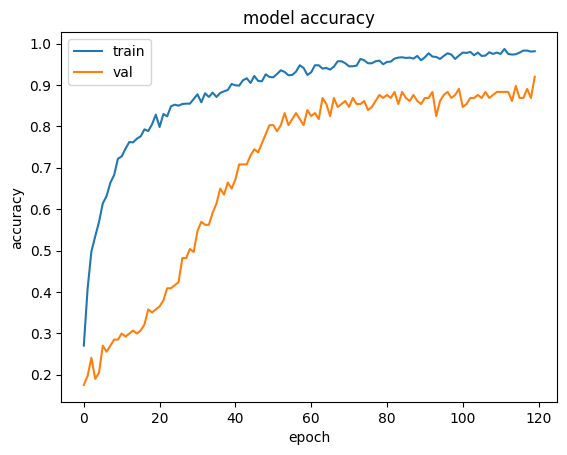

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

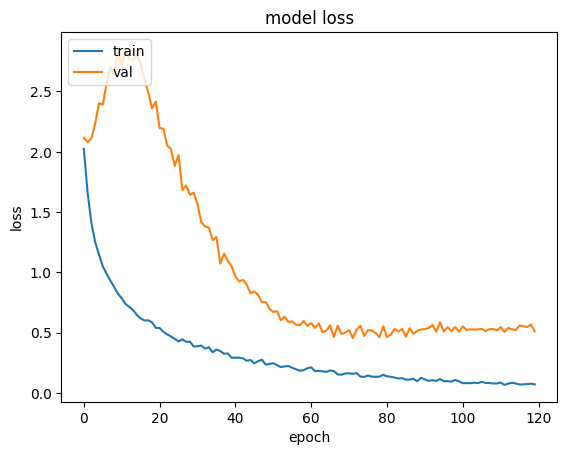

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [24]:
# Get the weights of the individual branch models
branch_weights = []

for branch_model in branch_models:
    branch_weights.append(branch_model.get_weights())

# # Print the weights for each branch
# for i, branch_weight in enumerate(branch_weights):
#     print(f"Weights for Branch {i + 1}:", branch_weight)

In [25]:
# Get the weights of the main model
main_model_weights = model.get_weights()

# # Print the weights for each layer
# for layer_weights in main_model_weights:
#     print(layer_weights)

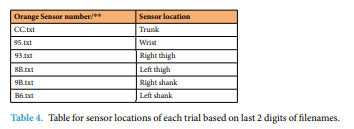

## Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# input_data = np.array(x_trains)

print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=128)
print("test loss, test acc:", results)


# # Generate predictions (probabilities -- the output of the last layer)
# # on new data using `predict`
# print("Generate predictions for 3 samples")
# predictions = model.predict(fft_x_tests, verbose=0)[:100]
# print("predictions shape:", predictions.shape)


#Predict
y_prediction = model.predict(X_test)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(y_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')

print("F1 score:", f1)

Evaluate on test data
2/2 [==============================] - 0s 35ms/step - loss: 0.8256 - accuracy: 0.8107
test loss, test acc: [0.8255835771560669, 0.8106995820999146]
8/8 [==============================] - 0s 23ms/step
[1 6 2 4 6 7 0 4 3 1 2 7 5 0 2 8 1 7 3 2 0 6 6 2 4 5 3 3 6 3 7 5 3 1 4 3 1
 3 4 2 8 3 4 3 8 5 7 7 4 4 1 6 2 0 6 4 3 3 1 4 8 1 4 0 1 0 1 3 6 2 1 1 6 0
 7 5 6 1 3 1 5 2 2 8 6 3 8 0 4 0 7 7 0 8 1 3 1 4 3 6 4 8 7 3 6 5 8 1 8 6 1
 7 5 8 4 5 8 6 4 6 1 1 5 3 5 0 5 0 2 0 4 0 6 2 0 1 1 2 7 4 7 5 6 1 2 6 8 2
 1 1 2 3 3 8 7 0 4 6 0 6 5 1 3 6 7 2 4 1 7 8 4 4 1 2 8 5 2 2 6 7 1 7 4 6 6
 2 7 5 4 0 7 3 0 0 4 6 1 7 7 2 5 4 4 8 8 4 4 8 7 1 1 3 6 6 2 1 3 5 3 3 4 7
 7 3 5 0 6 7 4 3 6 1 6 1 6 5 4 0 6 6 0 6 1]
[1 6 2 4 6 7 0 4 3 3 3 7 2 0 2 8 2 5 3 2 4 6 6 2 3 5 3 3 6 2 7 5 4 1 4 2 1
 3 0 0 8 3 4 3 8 5 7 7 4 4 5 6 2 3 3 4 4 6 1 4 8 1 4 0 1 0 3 3 6 0 1 1 6 0
 7 0 6 1 3 1 5 2 2 8 6 3 8 3 5 2 7 7 0 8 1 3 1 4 3 0 4 8 5 5 3 5 8 1 8 6 1
 7 5 8 4 5 8 6 4 6 2 1 5 3 5 4 3 0 2 0 4 0 6 2 2 2 1 2 8 5 

In [27]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

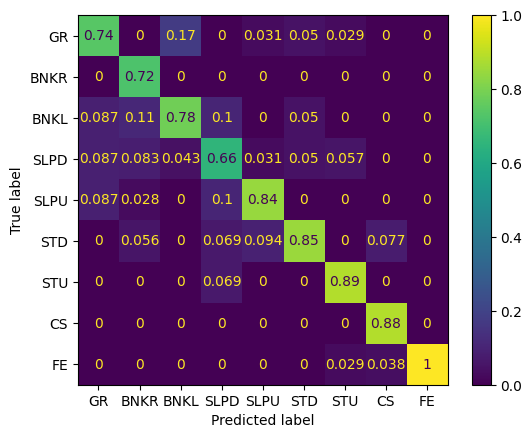

In [28]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['GR', 'BNKR', 'BNKL', 'SLPD', 'SLPU', 'STD', 'STU', 'CS', 'FE'])

cm_display.plot()
plt.show()

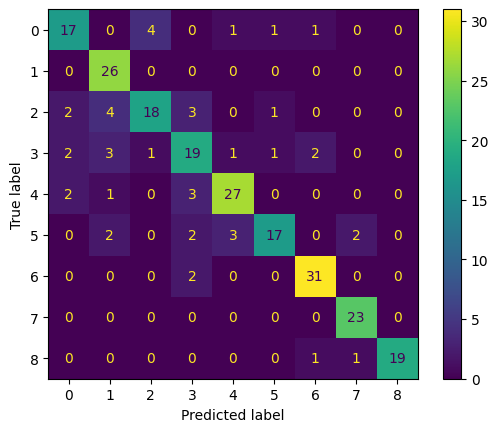

In [29]:
ConfusionMatrixDisplay.from_predictions(Y_9B_test_proc, y_prediction)

In [30]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE